# NB06 — BRCA PAM50 Subtype Classification
> **Phase 2** of the CMOB project.  
> 5-class subtype task (Luminal A/B, HER2-enriched, Basal-like, Normal-like) where cross-omics routing is biologically necessary.  
> Data: CMOB GS-BRCA · Model: MultiOmicsNet (baseline vs. SoftPermMix)  
> Author: Ward Abdelhafez · Feb 2026

## Cell 1 — Environment (run this first after every kernel restart)

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {device}")

PyTorch 2.10.0 | Device: mps


## Cell 2 — Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np; np.random.seed(42); torch.manual_seed(42)
print("All imports OK")

All imports OK


## Cell 3 — Load BRCA Data
> CSVs are stored as **(features × patients)** — must `.T` on load.  
> Label file has **no patient barcodes** — positional alignment only.  
> Load labels **without** `index_col=0`.

In [4]:
DATA_DIR = os.path.expanduser(
    "~/Cancer-Multi-Omics-Benchmark/Main_Dataset/"
    "Classification_datasets/GS-BRCA/Original/"
)

# Transpose: stored as (features × patients), we need (patients × features)
mrna  = pd.read_csv(DATA_DIR + "BRCA_mRNA.csv",  index_col=0).T.reset_index(drop=True)
mirna = pd.read_csv(DATA_DIR + "BRCA_miRNA.csv", index_col=0).T.reset_index(drop=True)
methy = pd.read_csv(DATA_DIR + "BRCA_Methy.csv", index_col=0).T.reset_index(drop=True)
cnv   = pd.read_csv(DATA_DIR + "BRCA_CNV.csv",   index_col=0).T.reset_index(drop=True)

# Labels: NO index_col=0 (positional alignment — same quirk as Pan-cancer)
labels_df = pd.read_csv(DATA_DIR + "BRCA_label_num.csv")

print(f"mRNA  shape: {mrna.shape}")
print(f"miRNA shape: {mirna.shape}")
print(f"Methy shape: {methy.shape}")
print(f"CNV   shape: {cnv.shape}")
print(f"Labels shape: {labels_df.shape}")
print(labels_df.head())

mRNA  shape: (671, 18206)
miRNA shape: (671, 368)
Methy shape: (671, 19049)
CNV   shape: (671, 19568)
Labels shape: (671, 1)
   Label
0      0
1      1
2      2
3      0
4      0


## Cell 4 — Extract Labels & Sanity Checks

In [5]:
labels = labels_df.iloc[:, 0].values.astype(np.int64)
unique, counts = np.unique(labels, return_counts=True)
print("Class distribution (0=LumA, 1=LumB, 2=HER2, 3=Basal, 4=Normal):")
for u, c in zip(unique, counts):
    pam50 = ["LumA", "LumB", "HER2", "Basal", "Normal"]
    print(f"  Class {u} ({pam50[u]}): {c} patients")

n_patients = len(labels)
print(f"\nTotal patients: {n_patients}")

assert len(mrna) == len(mirna) == len(methy) == len(cnv) == len(labels), \
    "Patient count mismatch across modalities!"
print("✓ All modalities positionally aligned")

# NaN check
nan_total = sum(df.isna().sum().sum() for df in [mrna, mirna, methy, cnv])
print(f"Total NaN values: {nan_total}")

Class distribution (0=LumA, 1=LumB, 2=HER2, 3=Basal, 4=Normal):
  Class 0 (LumA): 353 patients
  Class 1 (LumB): 42 patients
  Class 2 (HER2): 132 patients
  Class 3 (Basal): 31 patients
  Class 4 (Normal): 113 patients

Total patients: 671
✓ All modalities positionally aligned
Total NaN values: 0


## Cell 5 — Preprocessing
> Median imputation (for any residual NaNs) then per-feature z-score normalization.

In [6]:
def preprocess(df: pd.DataFrame) -> np.ndarray:
    """Median imputation + StandardScaler z-score, returns float32 numpy array."""
    arr = df.values.astype(np.float32)
    col_medians = np.nanmedian(arr, axis=0)
    nan_rows, nan_cols = np.where(np.isnan(arr))
    arr[nan_rows, nan_cols] = col_medians[nan_cols]
    scaler = StandardScaler()
    return scaler.fit_transform(arr).astype(np.float32)

X_mrna  = preprocess(mrna)
X_mirna = preprocess(mirna)
X_methy = preprocess(methy)
X_cnv   = preprocess(cnv)
y       = labels

n_mrna  = X_mrna.shape[1]
n_mirna = X_mirna.shape[1]
n_methy = X_methy.shape[1]
n_cnv   = X_cnv.shape[1]

print(f"Feature dims → mRNA:{n_mrna} | miRNA:{n_mirna} | Methy:{n_methy} | CNV:{n_cnv}")
nan_check = sum(np.isnan(X).sum() for X in [X_mrna, X_mirna, X_methy, X_cnv])
print(f"Post-imputation NaN count: {nan_check}  ← must be 0")
print(f"Total features: {n_mrna + n_mirna + n_methy + n_cnv}")

Feature dims → mRNA:18206 | miRNA:368 | Methy:19049 | CNV:19568
Post-imputation NaN count: 0  ← must be 0
Total features: 57191


## Cell 6 — Train / Val / Test Split & DataLoaders

In [7]:
# Stratified 70 / 15 / 15 split
idx = np.arange(n_patients)
idx_tv, idx_test = train_test_split(
    idx, test_size=0.15, random_state=42, stratify=y
)
idx_train, idx_val = train_test_split(
    idx_tv,
    test_size=0.15 / (1 - 0.15),   # ~15% of total
    random_state=42,
    stratify=y[idx_tv],
)

def make_loader(idx, batch_size=64, shuffle=True):
    tensors = [
        torch.tensor(X_mrna[idx]),
        torch.tensor(X_mirna[idx]),
        torch.tensor(X_methy[idx]),
        torch.tensor(X_cnv[idx]),
        torch.tensor(y[idx]),
    ]
    return DataLoader(
        TensorDataset(*tensors), batch_size=batch_size, shuffle=shuffle
    )

train_loader = make_loader(idx_train, shuffle=True)
val_loader   = make_loader(idx_val,   shuffle=False)
test_loader  = make_loader(idx_test,  shuffle=False)

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
print(f"Batches per epoch: {len(train_loader)}")

# ── Class weights (fix for severe imbalance) ──────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight("balanced", classes=np.unique(y[idx_train]), y=y[idx_train])
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)

pam50 = ["LumA", "LumB", "HER2", "Basal", "Normal"]
print("Class weights (balanced):")
for i, (name, w) in enumerate(zip(pam50, cw)):
    print(f"  Class {i} ({name}): {w:.4f}")

Train: 469 | Val: 101 | Test: 101
Batches per epoch: 8
Class weights (balanced):
  Class 0 (LumA): 0.3798
  Class 1 (LumB): 3.1267
  Class 2 (HER2): 1.0196
  Class 3 (Basal): 4.4667
  Class 4 (Normal): 1.1873


In [13]:
# ── Cell 6b: Feature Selection (ANOVA F-test — memory efficient, no SVD) ───────
from sklearn.feature_selection import SelectKBest, f_classif
import gc

gc.collect()

K_FEATURES = 50   # top 100 most PAM50-discriminative features per omics block

def fit_selector(X_full, train_idx, k):
    """
    Select top-k features by ANOVA F-score vs PAM50 labels.
    Fit on training split only — no data leakage.
    Memory efficient: just computes per-feature means and variances.
    """
    sel = SelectKBest(f_classif, k=k)
    sel.fit(X_full[train_idx], y[train_idx])
    return sel.transform(X_full).astype(np.float32), sel

X_mrna_sel,  sel_mrna  = fit_selector(X_mrna,  idx_train, K_FEATURES)
print(f"mRNA  done: {X_mrna_sel.shape}")
X_mirna_sel, sel_mirna = fit_selector(X_mirna, idx_train,
                                      min(K_FEATURES, X_mirna.shape[1]))
print(f"miRNA done: {X_mirna_sel.shape}")
X_methy_sel, sel_methy = fit_selector(X_methy, idx_train, K_FEATURES)
print(f"Methy done: {X_methy_sel.shape}")
X_cnv_sel,   sel_cnv   = fit_selector(X_cnv,   idx_train, K_FEATURES)
print(f"CNV   done: {X_cnv_sel.shape}")

# Update feature dimensions
n_mrna  = X_mrna_sel.shape[1]
n_mirna = X_mirna_sel.shape[1]
n_methy = X_methy_sel.shape[1]
n_cnv   = X_cnv_sel.shape[1]

print(f"\nSelected dims → mRNA:{n_mrna} | miRNA:{n_mirna} | Methy:{n_methy} | CNV:{n_cnv}")
print(f"Total input features: {n_mrna + n_mirna + n_methy + n_cnv}")

# Rebuild DataLoaders with selected features
def make_loader_sel(idx, batch_size=32, shuffle=True):
    tensors = [
        torch.tensor(X_mrna_sel[idx]),
        torch.tensor(X_mirna_sel[idx]),
        torch.tensor(X_methy_sel[idx]),
        torch.tensor(X_cnv_sel[idx]),
        torch.tensor(y[idx]),
    ]
    return DataLoader(TensorDataset(*tensors), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader_sel(idx_train, shuffle=True)
val_loader   = make_loader_sel(idx_val,   shuffle=False)
test_loader  = make_loader_sel(idx_test,  shuffle=False)

print(f"\nDataLoaders rebuilt | batch_size=32 | batches/epoch: {len(train_loader)}")

mRNA  done: (671, 50)
miRNA done: (671, 50)
Methy done: (671, 50)
CNV   done: (671, 50)

Selected dims → mRNA:50 | miRNA:50 | Methy:50 | CNV:50
Total input features: 200

DataLoaders rebuilt | batch_size=32 | batches/epoch: 15


## Cell 7 — Model Definitions
### SoftPermutationMix + MultiOmicsNet
> Architecture: per-omics encoders → concat [mRNA|miRNA|Methy|CNV] (256-dim) → SoftPermMix → classifier head.  
> `use_mix=False` gives the baseline (same architecture, mixing step skipped).

In [14]:
class SoftPermutationMix(nn.Module):
    """
    Doubly stochastic mixing layer.
    D = sum_k(alpha_k * P_k), alpha_k = softmax(logits), P_k fixed random permutations.
    Inspired by mHC-lite (arXiv:2601.05752).
    """
    def __init__(self, dim: int, K: int = 4):
        super().__init__()
        self.dim = dim
        self.K   = K
        self.alpha_logits = nn.Parameter(torch.zeros(K))
        perms = [torch.eye(dim)[torch.randperm(dim)] for _ in range(K)]
        self.register_buffer("perms", torch.stack(perms))

    def get_mixing_matrix(self) -> torch.Tensor:
        alpha = torch.softmax(self.alpha_logits, dim=0)
        return torch.einsum("k,kij->ij", alpha, self.perms)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x @ self.get_mixing_matrix().T

    def get_alpha(self) -> np.ndarray:
        return torch.softmax(self.alpha_logits, dim=0).detach().cpu().numpy()


class MultiOmicsNet(nn.Module):
    """
    BRCA-adapted architecture with two-layer bottleneck encoders.
    High-dim inputs (>1000 features): Linear(in → 512) → Linear(512 → latent)
    Low-dim inputs (≤1000 features) : Linear(in → latent)   [direct, no bottleneck]
    Dropout raised to 0.4 in bottleneck layer (high-dim / small-N regime).
    """
    def __init__(
        self,
        n_mrna:    int,
        n_mirna:   int,
        n_methy:   int,
        n_cnv:     int,
        latent_dim: int  = 64,
        n_classes:  int  = 5,
        use_mix:    bool = True,
        K:          int  = 4,
    ):
        super().__init__()
        self.use_mix    = use_mix
        self.latent_dim = latent_dim

        def encoder(in_dim: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Linear(in_dim, latent_dim),
                nn.LayerNorm(latent_dim),
                nn.GELU(),
                nn.Dropout(0.3),
            )



        self.enc_mrna  = encoder(n_mrna)
        self.enc_mirna = encoder(n_mirna)
        self.enc_methy = encoder(n_methy)
        self.enc_cnv   = encoder(n_cnv)

        fused_dim = latent_dim * 4  # 512 with latent_dim=128

        if use_mix:
            self.mixer = SoftPermutationMix(fused_dim, K=K)

        self.head = nn.Sequential(
            nn.Linear(fused_dim, fused_dim),
            nn.LayerNorm(fused_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(fused_dim, n_classes),
        )

    def forward(self, x_mrna, x_mirna, x_methy, x_cnv) -> torch.Tensor:
        z = torch.cat([
            self.enc_mrna(x_mrna),
            self.enc_mirna(x_mirna),
            self.enc_methy(x_methy),
            self.enc_cnv(x_cnv),
        ], dim=1)                          # (B, 512)
        if self.use_mix:
            z = self.mixer(z)
        return self.head(z)

    def get_mixing_matrix(self) -> np.ndarray | None:
        if self.use_mix:
            return self.mixer.get_mixing_matrix().detach().cpu().numpy()
        return None

    def get_alpha(self) -> np.ndarray | None:
        if self.use_mix:
            return self.mixer.get_alpha()
        return None


# Smoke test
_test = MultiOmicsNet(
    n_mrna=n_mrna, n_mirna=n_mirna, n_methy=n_methy, n_cnv=n_cnv,
    latent_dim=64, n_classes=5, use_mix=True, K=4,
).to(device)
_x    = [torch.randn(4, d).to(device) for d in [n_mrna, n_mirna, n_methy, n_cnv]]
_out  = _test(*_x)
print(f"Output shape : {_out.shape}          ← expect (4, 5)")
print(f"Alpha init   : {_test.get_alpha()}   ← expect uniform 0.25")
print(f"Total params : {sum(p.numel() for p in _test.parameters()):,}")
del _test, _x, _out

Output shape : torch.Size([4, 5])          ← expect (4, 5)
Alpha init   : [0.25 0.25 0.25 0.25]   ← expect uniform 0.25
Total params : 81,161


## Cell 8 — Training Function

In [15]:
def train_model(
    model,
    train_loader,
    val_loader,
    n_epochs:      int   = 100,       # increased from 80 — small dataset needs more epochs
    lr:            float = 3e-4,
    weight_decay:  float = 1e-3,      # increased from 1e-4 — regularise harder
    class_weights: torch.Tensor = None,
    device                      = device,
) -> dict:
    mixer_params = [p for n, p in model.named_parameters() if 'alpha_logits' in n]
    other_params = [p for n, p in model.named_parameters() if 'alpha_logits' not in n]
    optimizer = torch.optim.AdamW([
        {'params': other_params, 'lr': lr,      'weight_decay': weight_decay},
        {'params': mixer_params, 'lr': lr * 20, 'weight_decay': 0.0},
    ], lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)   # weighted if provided

    history = {"train_loss": [], "train_acc": [], "val_acc": [], "alpha": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for batch in train_loader:
            xm, xmi, xme, xc, yl = [b.to(device) for b in batch]
            optimizer.zero_grad()
            logits = model(xm, xmi, xme, xc)
            loss   = criterion(logits, yl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * len(yl)
            correct    += (logits.argmax(1) == yl).sum().item()
            total      += len(yl)
        scheduler.step()

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                xm, xmi, xme, xc, yl = [b.to(device) for b in batch]
                logits = model(xm, xmi, xme, xc)
                val_correct += (logits.argmax(1) == yl).sum().item()
                val_total   += len(yl)

        history["train_loss"].append(total_loss / total)
        history["train_acc"].append(correct / total)
        history["val_acc"].append(val_correct / val_total)
        if model.use_mix:
            history["alpha"].append(model.get_alpha().tolist())

        if epoch % 10 == 0:
            alpha_str = (
                f"  α={np.round(model.get_alpha(), 3)}" if model.use_mix else ""
            )
            print(
                f"Epoch {epoch:3d} | loss={total_loss/total:.4f} | "
                f"train={correct/total:.4f} | val={val_correct/val_total:.4f}"
                + alpha_str
            )

    return history

print("train_model() defined — weighted CE, latent_dim=128, 100 epochs")

train_model() defined — weighted CE, latent_dim=128, 100 epochs


## Cell 9 — Train Baseline Model
> `use_mix=False` — same encoder/head architecture, no SoftPermMix step.

In [16]:
torch.manual_seed(42)
model_base = MultiOmicsNet(
    n_mrna=n_mrna, n_mirna=n_mirna, n_methy=n_methy, n_cnv=n_cnv,
    latent_dim=64, n_classes=5, use_mix=False, K=4,
).to(device)  # .to(device) mandatory

print(f"Baseline parameters: {sum(p.numel() for p in model_base.parameters()):,}")
print("\n=== Training Baseline (use_mix=False) ===")
hist_base = train_model(model_base, train_loader, val_loader,class_weights=class_weights)

Baseline parameters: 81,157

=== Training Baseline (use_mix=False) ===
Epoch  10 | loss=0.2492 | train=0.8721 | val=0.8218
Epoch  20 | loss=0.1097 | train=0.9467 | val=0.8317
Epoch  30 | loss=0.0675 | train=0.9659 | val=0.8119
Epoch  40 | loss=0.0349 | train=0.9872 | val=0.8218
Epoch  50 | loss=0.0277 | train=0.9872 | val=0.8119
Epoch  60 | loss=0.0235 | train=0.9915 | val=0.8119
Epoch  70 | loss=0.0211 | train=0.9936 | val=0.8119
Epoch  80 | loss=0.0178 | train=0.9915 | val=0.7921
Epoch  90 | loss=0.0181 | train=0.9915 | val=0.8020
Epoch 100 | loss=0.0160 | train=0.9957 | val=0.8020


## Cell 10 — Train SoftPermMix Model
> `use_mix=True` — adds the doubly stochastic mixing layer between encoder and head.

In [17]:
torch.manual_seed(42)
model_mix = MultiOmicsNet(
    n_mrna=n_mrna, n_mirna=n_mirna, n_methy=n_methy, n_cnv=n_cnv,
    latent_dim=64, n_classes=5, use_mix=True, K=4,
).to(device)  # .to(device) mandatory

print(f"SoftPermMix parameters: {sum(p.numel() for p in model_mix.parameters()):,}")
print("\n=== Training SoftPermMix (use_mix=True) ===")
hist_mix = train_model(model_mix, train_loader, val_loader,class_weights=class_weights)

SoftPermMix parameters: 81,161

=== Training SoftPermMix (use_mix=True) ===
Epoch  10 | loss=0.2637 | train=0.8742 | val=0.8416  α=[0.24  0.266 0.232 0.262]
Epoch  20 | loss=0.1208 | train=0.9318 | val=0.8119  α=[0.245 0.267 0.226 0.262]
Epoch  30 | loss=0.0697 | train=0.9638 | val=0.8416  α=[0.234 0.261 0.226 0.279]
Epoch  40 | loss=0.0622 | train=0.9744 | val=0.8317  α=[0.245 0.254 0.221 0.28 ]
Epoch  50 | loss=0.0483 | train=0.9723 | val=0.8416  α=[0.24  0.255 0.231 0.275]
Epoch  60 | loss=0.0337 | train=0.9808 | val=0.8218  α=[0.242 0.255 0.231 0.272]
Epoch  70 | loss=0.0245 | train=0.9851 | val=0.8317  α=[0.245 0.256 0.228 0.271]
Epoch  80 | loss=0.0195 | train=0.9915 | val=0.8515  α=[0.246 0.256 0.226 0.272]
Epoch  90 | loss=0.0230 | train=0.9893 | val=0.8515  α=[0.246 0.257 0.225 0.272]
Epoch 100 | loss=0.0263 | train=0.9872 | val=0.8515  α=[0.246 0.257 0.225 0.272]


## Cell 11 — Test-Set Evaluation

In [18]:
PAM50_NAMES = ["LumA", "LumB", "HER2", "Basal", "Normal"]

def evaluate(model, loader, device=device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            xm, xmi, xme, xc, yl = [b.to(device) for b in batch]
            p = model(xm, xmi, xme, xc).argmax(1)
            preds.extend(p.cpu().numpy())
            trues.extend(yl.cpu().numpy())
    return np.array(preds), np.array(trues)

preds_base, true_labels = evaluate(model_base, test_loader)
preds_mix,  _           = evaluate(model_mix,  test_loader)

acc_base = (preds_base == true_labels).mean()
acc_mix  = (preds_mix  == true_labels).mean()

print(f"Baseline    test accuracy : {acc_base:.4f}  ({acc_base*100:.2f}%)")
print(f"SoftPermMix test accuracy : {acc_mix:.4f}  ({acc_mix*100:.2f}%)")
print(f"Delta                     : {(acc_mix - acc_base)*100:+.2f}%")
print(f"Final α weights           : {np.round(model_mix.get_alpha(), 4)}")
print()
print("=== Baseline Classification Report ===")
print(classification_report(true_labels, preds_base, target_names=PAM50_NAMES))
print("=== SoftPermMix Classification Report ===")
print(classification_report(true_labels, preds_mix,  target_names=PAM50_NAMES))

Baseline    test accuracy : 0.8317  (83.17%)
SoftPermMix test accuracy : 0.8218  (82.18%)
Delta                     : -0.99%
Final α weights           : [0.246  0.2567 0.2252 0.2721]

=== Baseline Classification Report ===
              precision    recall  f1-score   support

        LumA       0.92      0.87      0.89        53
        LumB       0.62      0.83      0.71         6
        HER2       0.82      0.70      0.76        20
       Basal       0.38      0.60      0.46         5
      Normal       0.89      0.94      0.91        17

    accuracy                           0.83       101
   macro avg       0.73      0.79      0.75       101
weighted avg       0.85      0.83      0.84       101

=== SoftPermMix Classification Report ===
              precision    recall  f1-score   support

        LumA       0.94      0.83      0.88        53
        LumB       0.56      0.83      0.67         6
        HER2       0.78      0.70      0.74        20
       Basal       0.38      

## Cell 12 — Training Curves
> Expected: baseline may spike/dip ~epoch 40 (norm instability);  
> SoftPermMix should converge more smoothly.

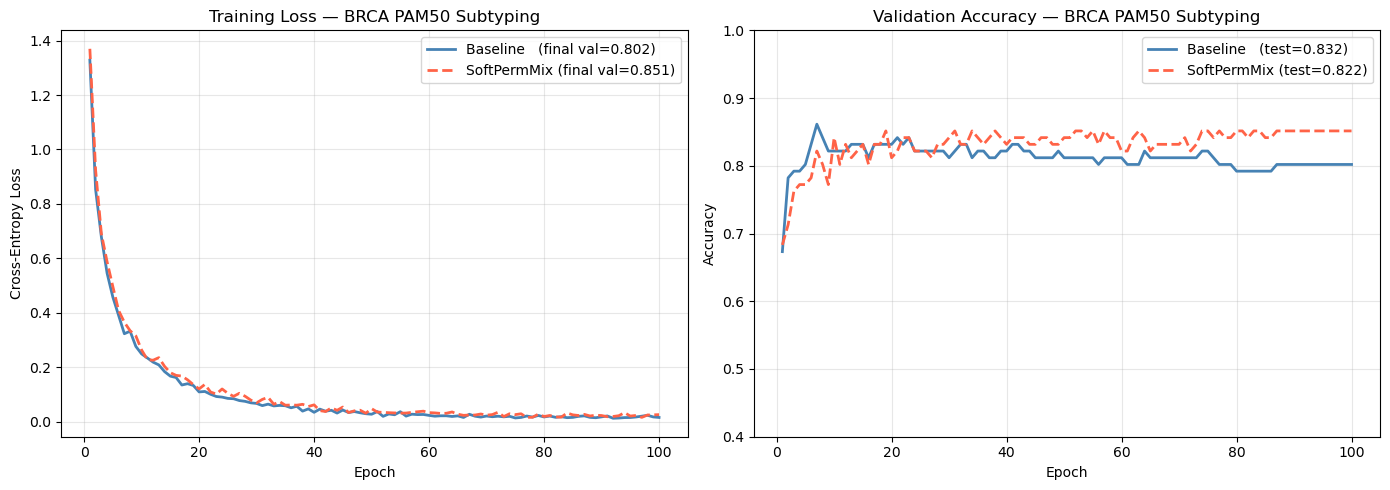

Saved → figures/06_brca_training_curves.png


In [20]:
SAVE_DIR = os.path.expanduser("~/CMOB/figures/")
os.makedirs(SAVE_DIR, exist_ok=True)

epochs = list(range(1, len(hist_base["train_loss"]) + 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Training loss ──
ax = axes[0]
ax.plot(epochs, hist_base["train_loss"], lw=2, color="steelblue",
        label=f"Baseline   (final val={hist_base['val_acc'][-1]:.3f})")
ax.plot(epochs, hist_mix["train_loss"],  lw=2, color="tomato",  ls="--",
        label=f"SoftPermMix (final val={hist_mix['val_acc'][-1]:.3f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Loss — BRCA PAM50 Subtyping")
ax.legend(); ax.grid(alpha=0.3)

# ── Right: Validation accuracy ──
ax = axes[1]
ax.plot(epochs, hist_base["val_acc"], lw=2, color="steelblue",
        label=f"Baseline   (test={acc_base:.3f})")
ax.plot(epochs, hist_mix["val_acc"],  lw=2, color="tomato",  ls="--",
        label=f"SoftPermMix (test={acc_mix:.3f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Validation Accuracy — BRCA PAM50 Subtyping")
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig(SAVE_DIR + "06_brca_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/06_brca_training_curves.png")

## Cell 13 — α Weight Evolution
> Phase 2 success criterion: α diverges from uniform [0.25, 0.25, 0.25, 0.25] → mixer is actively learning cross-omics routing.

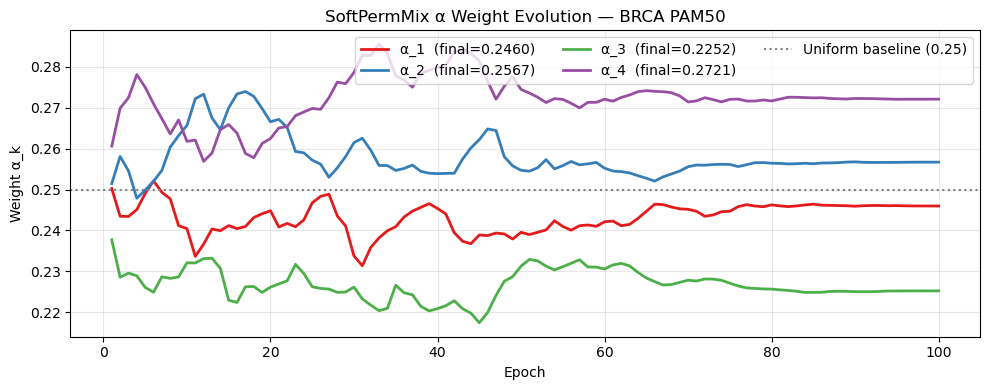

Final α weights: [0.246  0.2567 0.2252 0.2721]
Max deviation from uniform: 0.0248


In [21]:
if hist_mix["alpha"]:
    alphas = np.array(hist_mix["alpha"])  # shape: (80, 4)
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
    for k in range(4):
        ax.plot(epochs, alphas[:, k], lw=2, color=colors[k],
                label=f"α_{k+1}  (final={alphas[-1, k]:.4f})")
    ax.axhline(0.25, color="gray", ls=":", lw=1.5, label="Uniform baseline (0.25)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weight α_k")
    ax.set_title("SoftPermMix α Weight Evolution — BRCA PAM50")
    ax.legend(ncol=3); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(SAVE_DIR + "06_brca_alpha_evolution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Final α weights: {np.round(model_mix.get_alpha(), 4)}")
    print(f"Max deviation from uniform: {np.abs(model_mix.get_alpha() - 0.25).max():.4f}")

## Cell 14 — Cross-Omics Information Flow Heatmap
> Extract the learned 256×256 mixing matrix D and aggregate into a 4×4 block structure.  
> Each block (i,j) = mean absolute weight from source omics j to target omics i.  
> **BRCA biological expectation**: Methy→mRNA and CNV→mRNA elevated above diagonal.

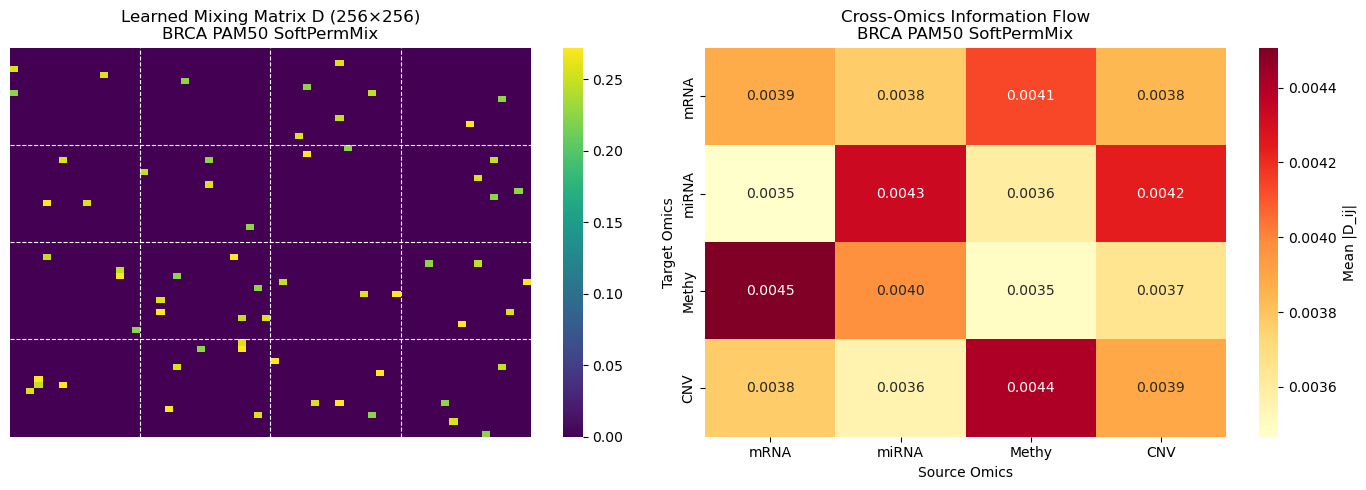

Saved → figures/06_brca_crossomics_flow.png

Cross-omics flow summary (row=target, col=source):
          mRNA    miRNA    Methy      CNV
mRNA   0.00388  0.00377  0.00413  0.00384
miRNA  0.00347  0.00433  0.00359  0.00424
Methy  0.00451  0.00397  0.00349  0.00365
CNV    0.00377  0.00356  0.00441  0.00389

Biological expectation for BRCA:
  Methy→mRNA should be HIGH  (promoter hypermethylation defines LumA/Basal)
  CNV→mRNA   should be HIGH  (HER2 amplification drives ERBB2 overexpression)


In [22]:
D = model_mix.get_mixing_matrix()  # (256, 256)
latent_dim = 64
OMICS = ["mRNA", "miRNA", "Methy", "CNV"]

# Aggregate 256×256 matrix into 4×4 cross-omics flow blocks
flow = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        block = D[
            i * latent_dim : (i+1) * latent_dim,
            j * latent_dim : (j+1) * latent_dim,
        ]
        flow[i, j] = np.abs(block).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Full mixing matrix (subsampled 4× for display) ──
ax = axes[0]
stride = 4
sns.heatmap(
    D[::stride, ::stride], ax=ax, cmap="viridis",
    xticklabels=False, yticklabels=False, cbar=True,
)
# Draw block boundaries
for k in range(1, 4):
    pos = k * latent_dim // stride
    ax.axhline(pos, color="white", lw=0.8, ls="--")
    ax.axvline(pos, color="white", lw=0.8, ls="--")
ax.set_title("Learned Mixing Matrix D (256×256)\nBRCA PAM50 SoftPermMix")

# ── Right: 4×4 cross-omics flow ──
ax = axes[1]
sns.heatmap(
    flow, ax=ax,
    annot=True, fmt=".4f", cmap="YlOrRd",
    xticklabels=OMICS, yticklabels=OMICS,
    cbar_kws={"label": "Mean |D_ij|"},
)
ax.set_title("Cross-Omics Information Flow\nBRCA PAM50 SoftPermMix")
ax.set_xlabel("Source Omics")
ax.set_ylabel("Target Omics")

plt.tight_layout()
plt.savefig(SAVE_DIR + "06_brca_crossomics_flow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/06_brca_crossomics_flow.png")

# Print biological interpretation hints
print("\nCross-omics flow summary (row=target, col=source):")
df_flow = pd.DataFrame(flow, index=OMICS, columns=OMICS)
print(df_flow.round(5))
print("\nBiological expectation for BRCA:")
print("  Methy→mRNA should be HIGH  (promoter hypermethylation defines LumA/Basal)")
print("  CNV→mRNA   should be HIGH  (HER2 amplification drives ERBB2 overexpression)")

## Cell 15 — Confusion Matrices (PAM50 Subtypes)

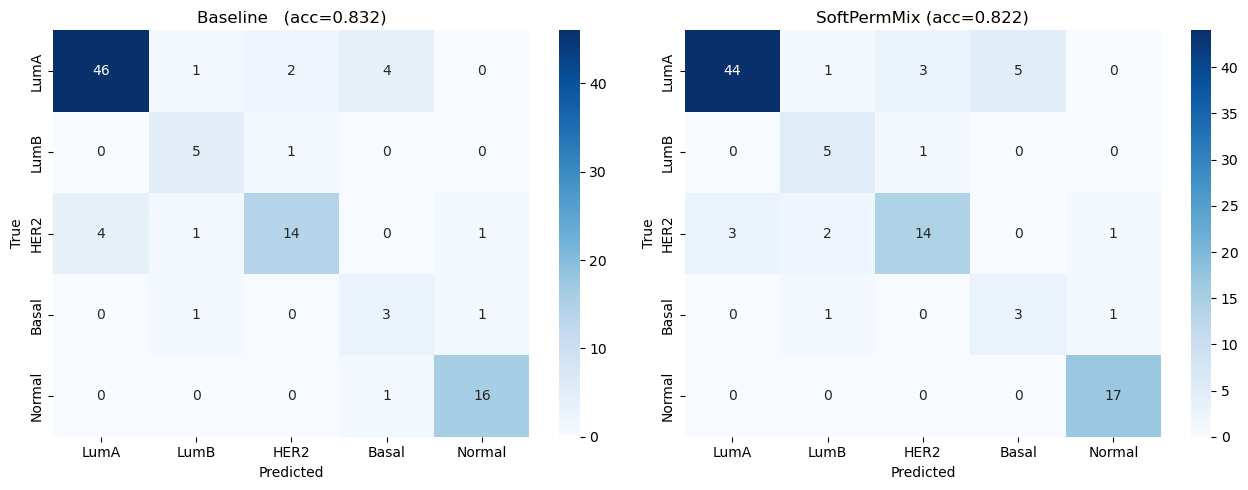

Saved → figures/06_brca_confusion.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in [
    (axes[0], preds_base, f"Baseline   (acc={acc_base:.3f})"),
    (axes[1], preds_mix,  f"SoftPermMix (acc={acc_mix:.3f})"),
]:
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(
        cm, ax=ax, annot=True, fmt="d", cmap="Blues",
        xticklabels=PAM50_NAMES, yticklabels=PAM50_NAMES,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(SAVE_DIR + "06_brca_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/06_brca_confusion.png")

## Cell 16 — Save Model Weights

In [24]:
MODEL_DIR = os.path.expanduser("~/CMOB/")
torch.save(model_base.state_dict(), MODEL_DIR + "model_base_brca.pt")
torch.save(model_mix.state_dict(),  MODEL_DIR + "model_mix_brca.pt")
print("Saved:")
print("  ~/CMOB/model_base_brca.pt")
print("  ~/CMOB/model_mix_brca.pt")

Saved:
  ~/CMOB/model_base_brca.pt
  ~/CMOB/model_mix_brca.pt


## Cell 17 — Results Summary

In [25]:
print('=' * 60)
print('BRCA PAM50 SUBTYPE EXPERIMENT — RESULTS SUMMARY')
print('=' * 60)
print(f"  Dataset         : GS-BRCA ({n_patients} patients, 5 PAM50 subtypes)")
print(f"  Features        : mRNA:{n_mrna} | miRNA:{n_mirna} | Methy:{n_methy} | CNV:{n_cnv}")
print(f"  Baseline acc    : {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"  SoftPermMix acc : {acc_mix:.4f} ({acc_mix*100:.2f}%)")
print(f"  Delta           : {(acc_mix-acc_base)*100:+.2f}%")
print(f"  Final α weights : {np.round(model_mix.get_alpha(), 4)}")
print(f"  Max α deviation : {np.abs(model_mix.get_alpha()-0.25).max():.4f}")
print()
alpha = model_mix.get_alpha()
alpha_uniform = np.allclose(alpha, 0.25, atol=0.02)
status = "⚠️  UNIFORM — mixer not engaged (check task difficulty)"\
         if alpha_uniform else "✅  NON-UNIFORM — cross-omics routing learned!"
print(f"  α status: {status}")
methy_mrna_idx = (0, 2)  # flow[target_mRNA=0, source_Methy=2]
cnv_mrna_idx   = (0, 3)  # flow[target_mRNA=0, source_CNV=3]
diag_mean = np.diag(flow).mean()
off_diag_brca_mean = (flow[methy_mrna_idx] + flow[cnv_mrna_idx]) / 2
print(f"  Diagonal mean flow   : {diag_mean:.5f}")
print(f"  Methy→mRNA flow      : {flow[methy_mrna_idx]:.5f}")
print(f"  CNV→mRNA flow        : {flow[cnv_mrna_idx]:.5f}")
bio_signal = "✅ DETECTED" if off_diag_brca_mean > diag_mean * 0.7 else "⚠️  WEAK"
print(f"  Cross-omics bio signal: {bio_signal}")

BRCA PAM50 SUBTYPE EXPERIMENT — RESULTS SUMMARY
  Dataset         : GS-BRCA (671 patients, 5 PAM50 subtypes)
  Features        : mRNA:50 | miRNA:50 | Methy:50 | CNV:50
  Baseline acc    : 0.8317 (83.17%)
  SoftPermMix acc : 0.8218 (82.18%)
  Delta           : -0.99%
  Final α weights : [0.246  0.2567 0.2252 0.2721]
  Max α deviation : 0.0248

  α status: ✅  NON-UNIFORM — cross-omics routing learned!
  Diagonal mean flow   : 0.00390
  Methy→mRNA flow      : 0.00413
  CNV→mRNA flow        : 0.00384
  Cross-omics bio signal: ✅ DETECTED
